## Autoencoder Workflow
Load preprocessed FIF hypnograms, train an LSTM autoencoder, and cluster the latent embeddings.


In [1]:
import glob
import os
import random
import re

import matplotlib.pyplot as plt
import mne
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import umap
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score, classification_report
from sklearn.model_selection import GroupShuffleSplit
from torch.utils.data import DataLoader, Dataset, Subset
from tqdm import tqdm

## Imports and Dependencies
Imports for training, clustering, and plotting.


In [6]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

def get_mode(arr):
    if len(arr) == 0:
        return 0
    vals, counts = np.unique(arr, return_counts=True)
    return vals[np.argmax(counts)]


class HypnogramDataset(Dataset):
    def __init__(
        self,
        fif_root,
        cohort_mode="sc_only",
        preprocessed_dir="preprocessed",
        target_len=1024,
        epoch_sec=30,
        min_valid_epochs=600,
    ):
        pattern = os.path.join(fif_root, "**", preprocessed_dir, "*.fif")
        all_files = sorted(glob.glob(pattern, recursive=True))

        self.files = self._filter_files(all_files, cohort_mode)

        self.target_len = target_len
        self.epoch_sec = epoch_sec
        self.cohort_mode = cohort_mode
        self.min_valid_epochs = min_valid_epochs

        self.data = []
        self.orig_lengths = []
        self.true_lengths = []
        self.cohorts = []
        self.subject_ids = []
        self.file_paths = []

        self._process_files()

    @staticmethod
    def _filter_files(files, cohort_mode):
        if cohort_mode == "sc_only":
            return [f for f in files if "sleep-cassette" in f]

        if cohort_mode == "st_only":
            return [f for f in files if "sleep-telemetry" in f]

        if cohort_mode == "both":
            return files

        return files

    @staticmethod
    def _extract_subject_id(file_path):
        basename = os.path.basename(file_path)
        match = re.match(r"(SC4\d{2}|ST7\d{2})", basename)
        return match.group(1) if match else "Unknown"

    def _process_files(self):
        for file in tqdm(self.files, desc=f"Loading {self.cohort_mode}"):
            raw = mne.io.read_raw_fif(file, preload=False, verbose="ERROR")

            total_duration = raw.times[-1]
            num_epochs = int(total_duration // self.epoch_sec)

            sequence = np.full(num_epochs, -1, dtype=np.int64)

            for annot in raw.annotations:
                start_ep = int(annot["onset"] // self.epoch_sec)
                end_ep = int((annot["onset"] + annot["duration"]) // self.epoch_sec)

                start_ep = max(0, start_ep)
                end_ep = min(num_epochs, end_ep)

                if end_ep <= start_ep:
                    continue

                try:
                    stage = int(annot["description"])
                except ValueError:
                    continue

                if stage != -1:
                    sequence[start_ep:end_ep] = stage

            valid_seq = sequence[(sequence != -1) & (sequence != 5)]

            true_len = len(valid_seq)

            if true_len < self.min_valid_epochs:
                print(
                    f"Skipping {file} due to insufficient valid epochs "
                    f"({true_len} epochs)."
                )
                continue

            seq = valid_seq[:self.target_len]
            effective_len = len(seq)

            pad_len = self.target_len - effective_len
            padded_seq = np.pad(seq, (0, pad_len), constant_values=5)

            self.data.append(padded_seq)
            self.orig_lengths.append(effective_len)
            self.true_lengths.append(true_len)
            self.cohorts.append(0 if "sleep-cassette" in file else 1)
            self.subject_ids.append(self._extract_subject_id(file))
            self.file_paths.append(file)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        seq = torch.tensor(self.data[idx], dtype=torch.long)
        orig_len = torch.tensor(self.orig_lengths[idx], dtype=torch.float32)
        cohort = torch.tensor(self.cohorts[idx], dtype=torch.long)

        return seq, orig_len, cohort


fif_root = os.path.join(".", "sleep-edf-database-expanded-1.0.0")

healthy_dataset = HypnogramDataset(
    fif_root,
    cohort_mode="sc_only",
    target_len=1024,
    min_valid_epochs=600,
)

unhealthy_dataset = HypnogramDataset(
    fif_root,
    cohort_mode="st_only",
    target_len=1024,
    min_valid_epochs=600,
)

if len(unhealthy_dataset) == 0:
    unhealthy_dataset = None


subject_ids = np.array(healthy_dataset.subject_ids)
indices = np.arange(len(healthy_dataset))

train_splitter = GroupShuffleSplit(
    n_splits=1,
    train_size=0.8,
    random_state=SEED,
)

train_indices, holdout_indices = next(
    train_splitter.split(indices, groups=subject_ids)
)

holdout_subjects = subject_ids[holdout_indices]

val_test_splitter = GroupShuffleSplit(
    n_splits=1,
    train_size=0.5,
    random_state=SEED,
)

val_rel, test_rel = next(
    val_test_splitter.split(holdout_indices, groups=holdout_subjects)
)

val_indices = holdout_indices[val_rel]
test_indices = holdout_indices[test_rel]


train_dataloader = DataLoader(
    Subset(healthy_dataset, train_indices),
    batch_size=16,
    shuffle=True,
)

val_dataloader = DataLoader(
    Subset(healthy_dataset, val_indices),
    batch_size=16,
    shuffle=False,
)

test_dataloader = DataLoader(
    Subset(healthy_dataset, test_indices),
    batch_size=16,
    shuffle=False,
)


print(f"Healthy nights loaded: {len(healthy_dataset)}")

if unhealthy_dataset is not None:
    print(f"Unhealthy nights loaded: {len(unhealthy_dataset)}")
else:
    print("No unhealthy nights loaded.")

print(f"Train nights: {len(train_indices)}")
print(f"Validation nights: {len(val_indices)}")
print(f"Test nights: {len(test_indices)}")

print(f"Train subjects: {len(set(subject_ids[train_indices]))}")
print(f"Validation subjects: {len(set(subject_ids[val_indices]))}")
print(f"Test subjects: {len(set(subject_ids[test_indices]))}")

Loading sc_only:   7%|▋         | 11/153 [00:35<07:37,  3.22s/it]

Skipping .\sleep-edf-database-expanded-1.0.0\sleep-cassette\preprocessed\SC4051E0-raw.fif due to insufficient valid epochs (551 epochs).


Loading sc_only:  54%|█████▍    | 83/153 [10:57<12:18, 10.54s/it]

Skipping .\sleep-edf-database-expanded-1.0.0\sleep-cassette\preprocessed\SC4431E0-raw.fif due to insufficient valid epochs (578 epochs).


Loading st_only: 100%|██████████| 44/44 [03:19<00:00,  4.53s/it]

Healthy nights loaded: 151
Unhealthy nights loaded: 44
Train nights: 119
Validation nights: 16
Test nights: 16
Train subjects: 62
Validation subjects: 8
Test subjects: 8



## Dataset Preparation
Build fixed-length hypnogram sequences from preprocessed FIF files.

Default behavior:
- train, validate, and test on `sleep-cassette` only
- keep `sleep-telemetry` separate and project it into the healthy latent space after training
- split healthy data by subject into train/validation/test, not by night
- use the existing `preprocessed` FIF files, which already have wake trimmed at both ends


## Model Definition
Define the LSTM autoencoder used for sequence reconstruction.


In [44]:
class HypnoLSTMAutoencoder(nn.Module):
    def __init__(self, seq_len=1024, num_classes=7, embed_dim=32, hidden_dim=64, latent_dim=32):
        super().__init__()
        self.seq_len = seq_len
        self.num_classes = num_classes # 0-4(Stages), 5(Pad), 6(Mask)
        
        self.embedding = nn.Embedding(num_embeddings=num_classes, embedding_dim=embed_dim)
        
        # Encoder
        self.encoder_lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc_mu = nn.Linear(hidden_dim * 2, latent_dim)
        
        # Decoder
        self.fc_decode = nn.Linear(latent_dim, hidden_dim * 2)
        self.decoder_lstm = nn.LSTM(hidden_dim * 2, hidden_dim, batch_first=True, bidirectional=True)
        self.classifier = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x, orig_lens=None):
        emb = self.embedding(x)  # (Batch, Seq_Len, Embed_Dim)
        enc_out, _ = self.encoder_lstm(emb)
        
        # Pool only over valid sequence lengths (ignores padding entirely)
        if orig_lens is not None:
            batch_size = x.size(0)
            seq_range = torch.arange(self.seq_len, device=x.device).unsqueeze(0).expand(batch_size, -1)
            mask = seq_range < orig_lens.unsqueeze(1)
            
            masked_enc_out = enc_out * mask.unsqueeze(-1).float()
            sum_enc = masked_enc_out.sum(dim=1)
            valid_lens = orig_lens.unsqueeze(-1).float().clamp(min=1.0)
            pooled = sum_enc / valid_lens
        else:
            pooled = enc_out.mean(dim=1)
            
        z = self.fc_mu(pooled)  # Latent representation

        # Decode by repeating the latent vector
        decoded_init = self.fc_decode(z)
        decoded_seq = decoded_init.unsqueeze(1).repeat(1, self.seq_len, 1)
        
        dec_out, _ = self.decoder_lstm(decoded_seq)
        logits = self.classifier(dec_out)
        
        return logits.transpose(1, 2), z

# Initialize with 7 classes (0-4 stages, 5 padding, 6 mask)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = HypnoLSTMAutoencoder(seq_len=1024, num_classes=7, latent_dim=32).to(device)
model.to(device)

Using device: cuda


HypnoLSTMAutoencoder(
  (embedding): Embedding(7, 32)
  (encoder_lstm): LSTM(32, 64, batch_first=True, bidirectional=True)
  (fc_mu): Linear(in_features=128, out_features=32, bias=True)
  (fc_decode): Linear(in_features=32, out_features=128, bias=True)
  (decoder_lstm): LSTM(128, 64, batch_first=True, bidirectional=True)
  (classifier): Linear(in_features=128, out_features=7, bias=True)
)

## Training the Autoencoder
Train with cross-entropy while ignoring padding tokens.


Training:  23%|██▎       | 116/500 [00:25<01:24,  4.54it/s]


Early stopping triggered after epoch 117
Test loss: 1.3107


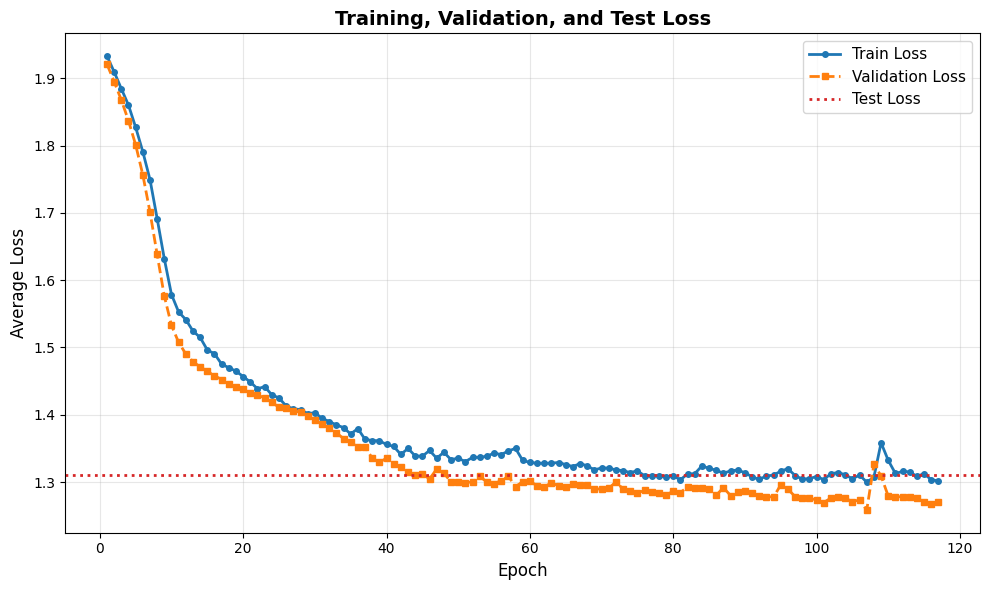

In [45]:
# %% [markdown]
# ## Training the Autoencoder
# Train with cross-entropy while correctly ignoring padding tokens.
# 

# %%
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)

#
# Gewichte für die Klassen: 0:Wake, 1:N1, 2:N2, 3:N3, 4:REM, 5:Pad, 6:Mask
# Ignore padding (5) so it doesn't artificially lower the loss
class_weights = torch.tensor([1.0, 2.0, 1.5, 6.0, 6.0, 0.0, 0.0], device=device)
criterion = nn.CrossEntropyLoss(weight=class_weights, ignore_index=5)

def apply_masking(seq, mask_prob=0.05, mask_token=6, pad_token=5):
    # Do not mask padding!
    mask = (torch.rand(seq.shape, device=seq.device) < mask_prob) & (seq != pad_token)
    masked_seq = seq.clone()
    masked_seq[mask] = mask_token
    return masked_seq

def evaluate_reconstruction_loss(dataloader):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for seq, orig_len, _ in dataloader:
            seq = seq.to(device)
            orig_len = orig_len.to(device)
            logits, _ = model(seq, orig_lens=orig_len)
            loss = criterion(logits, seq)
            total_loss += loss.item()
    return total_loss / max(1, len(dataloader))

num_epochs = int(os.environ.get("AUTOENCODER_NUM_EPOCHS", 500))
train_losses, val_losses = [],[]
best_val_loss = float("inf")
best_model_state = None
epochs_without_improvement = 0

for epoch in tqdm(range(num_epochs), desc="Training"):
    model.train()
    total_train_loss = 0.0

    for seq, orig_len, _ in train_dataloader:
        seq = seq.to(device)
        orig_len = orig_len.to(device)
        
        masked_seq = apply_masking(seq, mask_prob=0.05) # 5% masking
        
        optimizer.zero_grad()
        logits, _ = model(masked_seq, orig_lens=orig_len)
        loss = criterion(logits, seq)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_train_loss += loss.item()

    train_losses.append(total_train_loss / len(train_dataloader))
    avg_val_loss = evaluate_reconstruction_loss(val_dataloader)
    val_losses.append(avg_val_loss)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_state = {name: tensor.detach().cpu().clone() for name, tensor in model.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= 10:
        print(f"\nEarly stopping triggered after epoch {epoch + 1}")
        break

if best_model_state is not None:
    model.load_state_dict(best_model_state)

test_loss = evaluate_reconstruction_loss(test_dataloader)
print(f"Test loss: {test_loss:.4f}")

# Plot Loss
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(train_losses) + 1), train_losses, marker='o', linestyle='-', linewidth=2, markersize=4, label='Train Loss')
plt.plot(range(1, len(val_losses) + 1), val_losses, marker='s', linestyle='--', linewidth=2, markersize=4, label='Validation Loss')
if "test_loss" in globals():
    plt.axhline(test_loss, color='tab:red', linestyle=':', linewidth=2, label='Test Loss')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Average Loss', fontsize=12)
plt.title('Training, Validation, and Test Loss', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



## Embedding Extraction and Clustering
Fit clustering and UMAP on healthy embeddings, then project the unhealthy cohort into that same learned space.


c:\Users\Micae\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Silhouette Score, healthy latent feature space: 0.2793

Healthy cluster clinical values:
         % Wake  % Light (N1+N2)  % Deep (N3)  % REM  Night_Length  \
Cluster                                                              
0          8.46            65.45         8.53  17.56        919.44   
1         54.58            32.32         5.74   7.36       1021.61   
2         16.71            64.57         2.92  15.80        960.80   
3          9.17            46.36        23.59  20.88        907.50   

         Used_Epochs_For_Percentages  
Cluster                               
0                             919.44  
1                            1021.61  
2                             960.80  
3                             907.50  

Unhealthy values after assignment to healthy clusters:
         % Wake  % Light (N1+N2)  % Deep (N3)  % REM  Night_Length  \
Cluster                                                              
0          4.37            65.35        10.00  20.28        

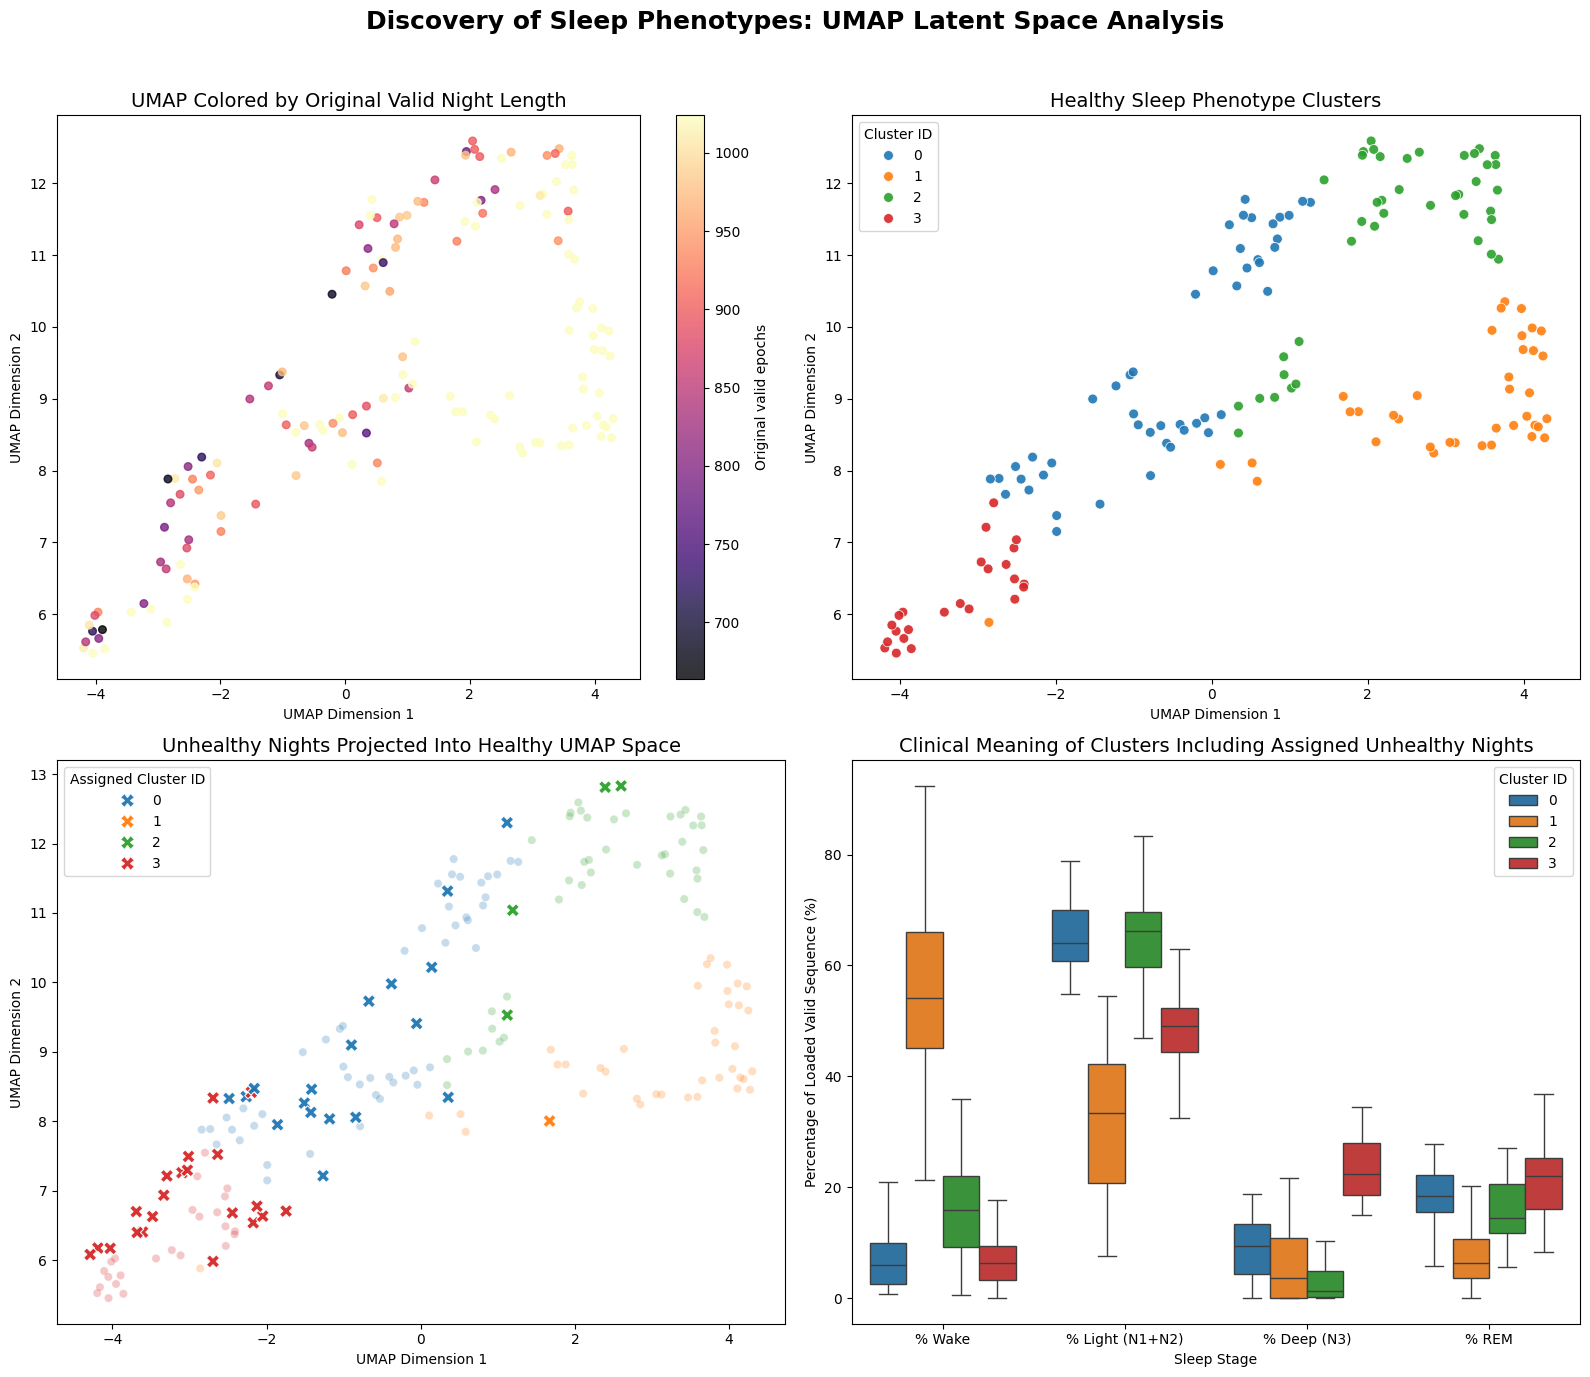

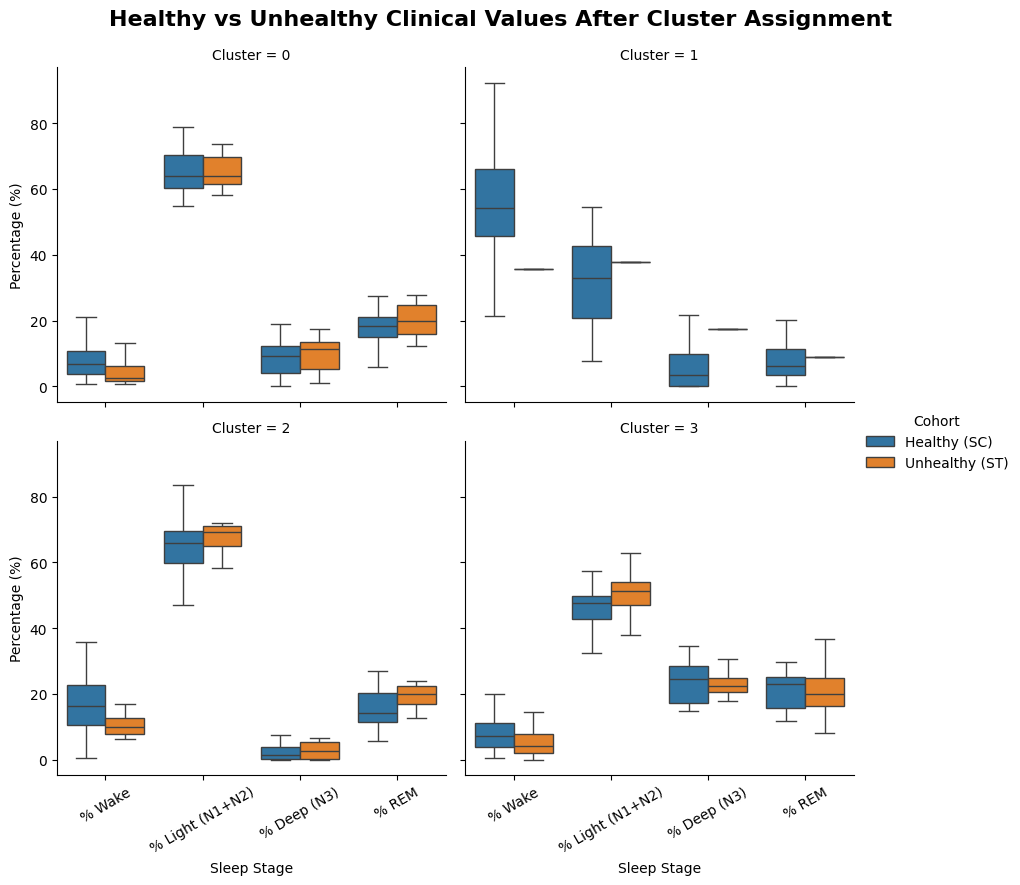

In [52]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.preprocessing import StandardScaler

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import umap


# ============================================================
# 1. Metrics from already-loaded dataset only
# ============================================================
def compute_metrics_from_loaded_dataset(source_dataset):
    """
    Uses only source_dataset.data and source_dataset.orig_lengths.
    
    Important:
    Sleep-stage percentages are calculated from the loaded sequence.
    In your dataset, that means the truncated/padded 1024 sequence.
    
    Night_Length uses source_dataset.orig_lengths.
    """

    rows = []

    for seq, orig_len in zip(source_dataset.data, source_dataset.orig_lengths):
        seq = np.asarray(seq)

        valid_seq = seq[(seq != -1) & (seq != 5)]
        used_len = len(valid_seq)

        if used_len > 0:
            perc_wake = np.mean(valid_seq == 0) * 100
            perc_light = np.mean((valid_seq == 1) | (valid_seq == 2)) * 100
            perc_deep = np.mean(valid_seq == 3) * 100
            perc_rem = np.mean(valid_seq == 4) * 100
        else:
            perc_wake = 0.0
            perc_light = 0.0
            perc_deep = 0.0
            perc_rem = 0.0

        rows.append({
            "% Wake": perc_wake,
            "% Light (N1+N2)": perc_light,
            "% Deep (N3)": perc_deep,
            "% REM": perc_rem,
            "Night_Length": orig_len,
            "Used_Epochs_For_Percentages": used_len,
        })

    return pd.DataFrame(rows)


# ============================================================
# 2. UMAP analysis
# ============================================================
def refresh_latent_analysis_umap_no_file_reload(
    n_clusters=4,
    n_neighbors=15,
    min_dist=0.1
):
    def extract_raw_features(source_dataset, desc):
        dataloader = DataLoader(
            source_dataset,
            batch_size=32,
            shuffle=False
        )

        embeddings = []
        cohorts = []

        model.eval()

        with torch.no_grad():
            for seq, orig_len, cohort in tqdm(dataloader, desc=desc, leave=False):
                seq = seq.to(device)
                orig_len = orig_len.to(device)

                _, z = model(seq, orig_lens=orig_len)

                embeddings.append(z.cpu().numpy())
                cohorts.append(cohort.numpy())

        if not embeddings:
            return np.empty((0, model.fc_mu.out_features)), np.empty(0)

        return np.vstack(embeddings), np.concatenate(cohorts)

    # -----------------------------
    # Extract healthy embeddings
    # -----------------------------
    healthy_raw, healthy_cohorts = extract_raw_features(
        healthy_dataset,
        "Extracting Healthy Features"
    )

    # -----------------------------
    # Scale using healthy only
    # -----------------------------
    scaler = StandardScaler()
    healthy_features = scaler.fit_transform(healthy_raw)

    # -----------------------------
    # Cluster healthy in latent space
    # -----------------------------
    clusterer = AgglomerativeClustering(
        n_clusters=n_clusters,
        linkage="ward"
    )

    healthy_cluster_labels = clusterer.fit_predict(healthy_features)

    healthy_silhouette = (
        silhouette_score(healthy_features, healthy_cluster_labels)
        if n_clusters > 1
        else np.nan
    )

    # -----------------------------
    # Fit UMAP on healthy only
    # -----------------------------
    safe_n_neighbors = max(
        2,
        min(n_neighbors, len(healthy_features) - 1)
    )

    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=safe_n_neighbors,
        min_dist=min_dist,
        metric="euclidean",
        random_state=SEED
    )

    healthy_umap = reducer.fit_transform(healthy_features)

    # -----------------------------
    # Project unhealthy into healthy UMAP space
    # Then assign unhealthy to nearest healthy cluster
    # -----------------------------
    if unhealthy_dataset is not None and len(unhealthy_dataset) > 0:
        unhealthy_raw, unhealthy_cohorts = extract_raw_features(
            unhealthy_dataset,
            "Extracting Unhealthy Features"
        )

        unhealthy_features = scaler.transform(unhealthy_raw)
        unhealthy_umap = reducer.transform(unhealthy_features)

        cluster_centroids = np.vstack([
            healthy_features[healthy_cluster_labels == k].mean(axis=0)
            for k in range(n_clusters)
        ])

        distances_to_clusters = pairwise_distances(
            unhealthy_features,
            cluster_centroids,
            metric="euclidean"
        )

        unhealthy_assigned_labels = distances_to_clusters.argmin(axis=1)

    else:
        unhealthy_features = np.empty((0, healthy_features.shape[1]))
        unhealthy_umap = np.empty((0, 2))
        unhealthy_assigned_labels = np.empty(0, dtype=int)

    return {
        "healthy_features": healthy_features,
        "healthy_cluster_labels": healthy_cluster_labels,
        "healthy_silhouette": healthy_silhouette,
        "healthy_umap": healthy_umap,
        "unhealthy_features": unhealthy_features,
        "unhealthy_umap": unhealthy_umap,
        "unhealthy_assigned_labels": unhealthy_assigned_labels,
    }


# ============================================================
# 3. Run analysis
# ============================================================
latent_analysis = refresh_latent_analysis_umap_no_file_reload(
    n_clusters=4,
    n_neighbors=15,
    min_dist=0.1
)

healthy_cluster_labels = latent_analysis["healthy_cluster_labels"]
healthy_umap = latent_analysis["healthy_umap"]

unhealthy_umap = latent_analysis["unhealthy_umap"]
unhealthy_assigned_labels = latent_analysis["unhealthy_assigned_labels"]

print(
    f"Silhouette Score, healthy latent feature space: "
    f"{latent_analysis['healthy_silhouette']:.4f}"
)


# ============================================================
# 4. Calculate values after cluster assignment
# ============================================================
df_healthy_metrics = compute_metrics_from_loaded_dataset(healthy_dataset)
df_healthy_metrics["Cluster"] = healthy_cluster_labels
df_healthy_metrics["Cohort"] = "Healthy (SC)"

if unhealthy_dataset is not None and len(unhealthy_dataset) > 0:
    df_unhealthy_metrics = compute_metrics_from_loaded_dataset(unhealthy_dataset)
    df_unhealthy_metrics["Cluster"] = unhealthy_assigned_labels
    df_unhealthy_metrics["Cohort"] = "Unhealthy (ST)"

    df_all_metrics = pd.concat(
        [df_healthy_metrics, df_unhealthy_metrics],
        ignore_index=True
    )
else:
    df_unhealthy_metrics = pd.DataFrame()
    df_all_metrics = df_healthy_metrics.copy()


print("\nHealthy cluster clinical values:")
print(
    df_healthy_metrics.groupby("Cluster")[[
        "% Wake",
        "% Light (N1+N2)",
        "% Deep (N3)",
        "% REM",
        "Night_Length",
        "Used_Epochs_For_Percentages"
    ]].mean().round(2)
)

if len(df_unhealthy_metrics) > 0:
    print("\nUnhealthy values after assignment to healthy clusters:")
    print(
        df_unhealthy_metrics.groupby("Cluster")[[
            "% Wake",
            "% Light (N1+N2)",
            "% Deep (N3)",
            "% REM",
            "Night_Length",
            "Used_Epochs_For_Percentages"
        ]].mean().round(2)
    )

    print("\nHealthy vs unhealthy values by cluster:")
    print(
        df_all_metrics.groupby(["Cohort", "Cluster"])[[
            "% Wake",
            "% Light (N1+N2)",
            "% Deep (N3)",
            "% REM",
            "Night_Length",
            "Used_Epochs_For_Percentages"
        ]].mean().round(2)
    )

    print("\nUnhealthy count assigned to each healthy cluster:")
    print(
        pd.Series(unhealthy_assigned_labels)
        .value_counts()
        .sort_index()
    )


# ============================================================
# 5. Plotting
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

fig.suptitle(
    "Discovery of Sleep Phenotypes: UMAP Latent Space Analysis",
    fontsize=18,
    fontweight="bold",
    y=0.98
)


# -----------------------------
# Plot 1: Night length
# -----------------------------
scatter1 = axes[0, 0].scatter(
    healthy_umap[:, 0],
    healthy_umap[:, 1],
    c=df_healthy_metrics["Night_Length"],
    cmap="magma",
    s=30,
    alpha=0.8
)

axes[0, 0].set_title(
    "UMAP Colored by Original Valid Night Length",
    fontsize=14
)
axes[0, 0].set_xlabel("UMAP Dimension 1")
axes[0, 0].set_ylabel("UMAP Dimension 2")

plt.colorbar(
    scatter1,
    ax=axes[0, 0],
    label="Original valid epochs"
)


# -----------------------------
# Plot 2: Healthy clusters
# -----------------------------
sns.scatterplot(
    x=healthy_umap[:, 0],
    y=healthy_umap[:, 1],
    hue=healthy_cluster_labels,
    palette="tab10",
    s=50,
    alpha=0.9,
    ax=axes[0, 1]
)

axes[0, 1].set_title(
    "Healthy Sleep Phenotype Clusters",
    fontsize=14
)
axes[0, 1].set_xlabel("UMAP Dimension 1")
axes[0, 1].set_ylabel("UMAP Dimension 2")
axes[0, 1].legend(title="Cluster ID")


# -----------------------------
# Plot 3: Unhealthy projected and assigned
# -----------------------------
sns.scatterplot(
    x=healthy_umap[:, 0],
    y=healthy_umap[:, 1],
    hue=healthy_cluster_labels,
    palette="tab10",
    s=35,
    alpha=0.25,
    ax=axes[1, 0],
    legend=False
)

if len(unhealthy_umap) > 0:
    sns.scatterplot(
        x=unhealthy_umap[:, 0],
        y=unhealthy_umap[:, 1],
        hue=unhealthy_assigned_labels,
        palette="tab10",
        marker="X",
        s=90,
        alpha=0.95,
        ax=axes[1, 0]
    )

axes[1, 0].set_title(
    "Unhealthy Nights Projected Into Healthy UMAP Space",
    fontsize=14
)
axes[1, 0].set_xlabel("UMAP Dimension 1")
axes[1, 0].set_ylabel("UMAP Dimension 2")
axes[1, 0].legend(title="Assigned Cluster ID")


# -----------------------------
# Plot 4: Clinical values after assignment
# -----------------------------
df_melted = df_all_metrics.melt(
    id_vars=["Cluster", "Cohort"],
    value_vars=[
        "% Wake",
        "% Light (N1+N2)",
        "% Deep (N3)",
        "% REM"
    ],
    var_name="Sleep Stage",
    value_name="Percentage (%)"
)

sns.boxplot(
    data=df_melted,
    x="Sleep Stage",
    y="Percentage (%)",
    hue="Cluster",
    palette="tab10",
    ax=axes[1, 1],
    showfliers=False
)

axes[1, 1].set_title(
    "Clinical Meaning of Clusters Including Assigned Unhealthy Nights",
    fontsize=14
)
axes[1, 1].set_ylabel("Percentage of Loaded Valid Sequence (%)")
axes[1, 1].set_xlabel("Sleep Stage")
axes[1, 1].legend(title="Cluster ID")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


# ============================================================
# 6. Optional extra plot: healthy vs unhealthy values separately
# ============================================================
if len(df_unhealthy_metrics) > 0:
    df_summary_melted = df_all_metrics.melt(
        id_vars=["Cluster", "Cohort"],
        value_vars=[
            "% Wake",
            "% Light (N1+N2)",
            "% Deep (N3)",
            "% REM"
        ],
        var_name="Sleep Stage",
        value_name="Percentage (%)"
    )

    g = sns.catplot(
        data=df_summary_melted,
        x="Sleep Stage",
        y="Percentage (%)",
        hue="Cohort",
        col="Cluster",
        kind="box",
        showfliers=False,
        height=4,
        aspect=1.1,
        col_wrap=2
    )

    g.fig.suptitle(
        "Healthy vs Unhealthy Clinical Values After Cluster Assignment",
        y=1.03,
        fontsize=16,
        fontweight="bold"
    )

    for ax in g.axes.flatten():
        ax.tick_params(axis="x", rotation=30)

    plt.show()